<a href="https://colab.research.google.com/github/haddybhaiya/unsupervised-learning-classes/blob/main/sand_grain_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle competitions download -c soil-grain-size-from-photos
!unzip -q soil-grain-size-from-photos.zip -d /content/soil_data

100% 334M/334M [00:05<00:00, 68.3MB/s]



In [11]:
import os

for root, dirs, files in os.walk("/content/soil_data"):
    print(root, len(files))

/content/soil_data 3
/content/soil_data/Test_All_Photos 0
/content/soil_data/Test_All_Photos/Test_All_Photos 35
/content/soil_data/Training-All_Photos_updated 0
/content/soil_data/Training-All_Photos_updated/Training-All_Photos_updated 127


load CSV


In [13]:
import pandas as pd
import glob

csv_files = glob.glob("/content/soil_data/**/*.csv", recursive=True)

for f in csv_files:
    print(f)

/content/soil_data/Training_labels_updated.csv
/content/soil_data/ppm_updated.csv
/content/soil_data/sample_submission.csv


In [15]:
train_df = pd.read_csv("/content/soil_data/Training_labels_updated.csv")
ppm_df = pd.read_csv("/content/soil_data/ppm_updated.csv")
sample_sub = pd.read_csv("/content/soil_data/sample_submission.csv")

In [16]:
display(train_df.head())
display(train_df.shape)
display(train_df.dtypes)

display(ppm_df.head())
display(sample_sub.head())

,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,F827,9.4904,19.3892,47.6257,89.5554,99.8965,99.9896,100.0000,100.0000,100.0000,100.0000,100.0
1,G190,5.2076,10.2425,23.7537,50.3113,75.8311,85.7233,90.9898,94.8969,98.5814,100.0000,100.0
2,H030,6.7833,10.9091,19.0599,37.3235,66.8349,96.4965,97.9530,99.5691,100.0000,100.0000,100.0
3,H037,0.9320,6.4500,16.3216,27.8019,34.6629,46.3652,62.7168,79.0523,89.7830,100.0000,100.0
4,H038,1.8218,5.1400,10.6113,18.2778,24.6420,35.0767,47.2345,63.3992,81.0851,95.7127,100.0


(24, 12)

,0
sample_id,object
0.002,float64
0.0063,float64
0.02,float64
0.063,float64
0.2,float64
0.63,float64
2,float64
6.3,float64
20,float64


,phone,camera,width,height,ppm
0,iPhone 14,iPhone 14,4032,3024,13.942
1,iPhone 16,iPhone 16,5712,4284,19.525
2,Motorola Edge,motorola edge 20,4000,1800,11.492
3,Motorola Edge 60 Fusion,Motorola Edge 60 fusion,4096,2304,12.465
4,Samsung A52,SM-A525F,9248,6936,26.330


,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,HPC_Airbus BS6-3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,HPC_Audorfring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,HPC_Muenster_BS6_9_0-10m,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,HPC_Airbus BS10-4bis7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HPC_Airbus BS12-5bis8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


data cleaning

In [17]:
train_df.isna().sum()

,0
sample_id,0
0.002,0
0.0063,0
0.02,0
0.063,0
0.2,0
0.63,0
2,0
6.3,0
20,0


In [18]:
train_df.duplicated().sum()

np.int64(0)

In [19]:
train_df["sample_id"].nunique()

24

In [ ]:
#since everything is good no need for cleaninng

Inspecting images


In [20]:
from PIL import Image
import matplotlib.pyplot as plt

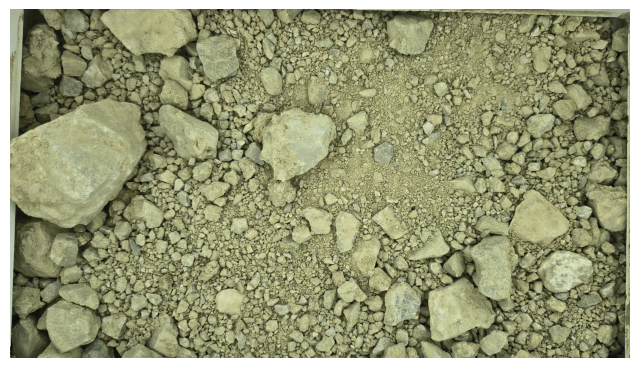

In [23]:
img = Image.open("/content/soil_data/Training-All_Photos_updated/Training-All_Photos_updated/Motorola_Edge_60_fusion_H374_01.jpg")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

TRAINING


In [24]:
import os
import re
import pandas as pd

TRAIN_IMG_DIR = "/content/soil_data/Training-All_Photos_updated/Training-All_Photos_updated"
TEST_IMG_DIR = "/content/soil_data/Test_All_Photos/Test_All_Photos"

train_images = sorted([
    os.path.join(TRAIN_IMG_DIR, f)
    for f in os.listdir(TRAIN_IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

test_images = sorted([
    os.path.join(TEST_IMG_DIR, f)
    for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Train images:", len(train_images))
print("Test images:", len(test_images))
print(train_images[:3])

Train images: 127
Test images: 35
['/content/soil_data/Training-All_Photos_updated/Training-All_Photos_updated/Motorola_Edge_60_fusion_H374_01.jpg', '/content/soil_data/Training-All_Photos_updated/Training-All_Photos_updated/Motorola_Edge_60_fusion_H374_02.jpg', '/content/soil_data/Training-All_Photos_updated/Training-All_Photos_updated/Motorola_Edge_60_fusion_H374_03.jpg']


In [25]:
train_sample_ids = set(train_df["sample_id"])

def get_sample_id(path, known_ids):
    filename = os.path.basename(path)

    for sample_id in known_ids:
        if sample_id in filename:
            return sample_id

    return None


train_meta = pd.DataFrame({
    "image_path": train_images
})

train_meta["sample_id"] = train_meta["image_path"].apply(
    lambda x: get_sample_id(x, train_sample_ids)
)

display(train_meta.head())
print(train_meta["sample_id"].isna().sum())

,image_path,sample_id
0,/content/soil_data/Training-All_Photos_updated...,H374
1,/content/soil_data/Training-All_Photos_updated...,H374
2,/content/soil_data/Training-All_Photos_updated...,H374
3,/content/soil_data/Training-All_Photos_updated...,F827
4,/content/soil_data/Training-All_Photos_updated...,F827


0


In [26]:
photo_counts = (
    train_meta
    .groupby("sample_id")
    .size()
    .sort_values(ascending=False)
)

display(photo_counts)

print("Min:", photo_counts.min())
print("Max:", photo_counts.max())
print("Mean:", photo_counts.mean())

,0
sample_id,
H038,8
H030,7
H183,7
H371,7
H668,7
H405,6
H181,6
H037,6
H617,6


Min: 3
Max: 8
Mean: 5.291666666666667


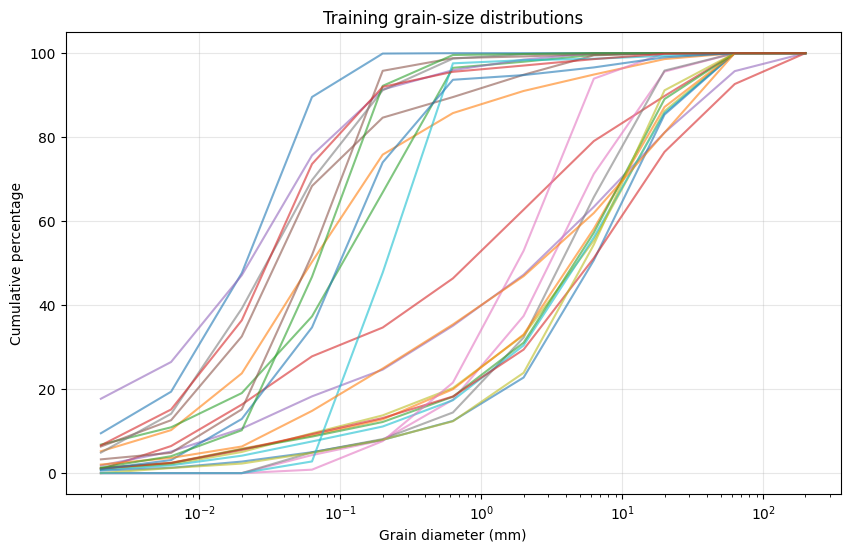

In [27]:
import numpy as np
import matplotlib.pyplot as plt

target_cols = [
    "0.002", "0.0063", "0.02", "0.063",
    "0.2", "0.63", "2", "6.3",
    "20", "63", "200"
]

diameters = np.array([float(x) for x in target_cols])

plt.figure(figsize=(10, 6))

for _, row in train_df.iterrows():
    plt.plot(
        diameters,
        row[target_cols].values.astype(float),
        alpha=0.6
    )

plt.xscale("log")
plt.xlabel("Grain diameter (mm)")
plt.ylabel("Cumulative percentage")
plt.title("Training grain-size distributions")
plt.grid(alpha=0.3)
plt.show()

In [28]:
from sklearn.model_selection import LeaveOneOut

X_dummy = np.arange(len(train_df))
y = train_df[target_cols].values

loo = LeaveOneOut()

baseline_preds = np.zeros_like(y)

for train_idx, val_idx in loo.split(X_dummy):
    baseline_preds[val_idx] = y[train_idx].mean(axis=0)

In [29]:
baseline_preds = np.clip(baseline_preds, 0, 100)
baseline_preds = np.maximum.accumulate(baseline_preds, axis=1)
baseline_preds[:, -1] = 100